# EE 446 TinyML — Knowledge Distillation with Pruning and Quantization  

## Student TODO Version: Compression of a DNN Using the UCI Human Activity Recognition Dataset

In this version, key parts of the notebook have been left for you to complete.  
Follow the instructions in each code cell and fill in the missing sections marked with `#<--- Enter your code here --->#`.


## 1. Environment Setup

This notebook assumes you are running it with the **`Python (tinyml-arduino)`** kernel.

Expected environment:
- TensorFlow 2.14.1
- TensorFlow Model Optimization 0.8.0
- NumPy, Pandas, Matplotlib, Scikit-learn
- No in-notebook package reinstallation is required

Use **Kernel → Change Kernel → `Python (tinyml-arduino)`** if needed.


In [1]:

import os
import math
import zipfile
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.14.1


## 2. Download and Extract the UCI HAR Dataset

The UCI HAR dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 human activity classes**
- A predefined **training split** and **test split**

This makes it a strong fit for a **fully connected DNN** and for TinyML-oriented compression experiments.


In [2]:

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = Path("uci_har_dataset.zip")
extract_dir = Path(".")

if not zip_path.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)

dataset_root = Path("UCI HAR Dataset")
if not dataset_root.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

print("Dataset ready at:", dataset_root.resolve())


Dataset ready at: /Users/kourosh/Desktop/EE446/EE446/LAB3/UCI HAR Dataset


## 3. Load the Data


In [3]:

def load_har_data(root_dir="UCI HAR Dataset"):
    root_dir = Path(root_dir)

    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32 and subtract 1
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32 and subtract 1

    X_train = pd.read_csv(root_dir / "train" / "X_train.txt", sep=r"\s+", header=None).values.astype("float32")
    y_train = pd.read_csv(root_dir / "train" / "y_train.txt", sep=r"\s+", header=None).values.ravel().astype("int32") - 1
    X_test = pd.read_csv(root_dir / "test" / "X_test.txt", sep=r"\s+", header=None).values.astype("float32")
    y_test = pd.read_csv(root_dir / "test" / "y_test.txt", sep=r"\s+", header=None).values.ravel().astype("int32") - 1
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data(dataset_root)

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection


In [4]:

label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Define the Teacher and Student Models

The **teacher model** is intentionally larger and more expressive.  
The **student model** is smaller and is the model we ultimately want to deploy.


In [5]:

def build_teacher_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

def build_student_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

teacher_model = build_teacher_model(num_features, num_classes)
student_baseline_model = build_student_model(num_features, num_classes)

teacher_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               287744    
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 6)                 774       
                                                                 
Total params: 452742 (1.73 MB)
Trainable params: 452742 (1.73 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 6. Train the Teacher Model


In [6]:

teacher_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

teacher_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

teacher_history = teacher_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=teacher_callbacks,
    verbose=1,
)


Epoch 1/20
92/92 [==============================] - 1s 3ms/step - loss: 0.4249 - accuracy: 0.8152 - val_loss: 0.1898 - val_accuracy: 0.9205
Epoch 2/20
92/92 [==============================] - 0s 3ms/step - loss: 0.1608 - accuracy: 0.9344 - val_loss: 0.1349 - val_accuracy: 0.9381
Epoch 3/20
92/92 [==============================] - 0s 3ms/step - loss: 0.1035 - accuracy: 0.9568 - val_loss: 0.3600 - val_accuracy: 0.8674
Epoch 4/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0951 - accuracy: 0.9641 - val_loss: 0.1684 - val_accuracy: 0.9368
Epoch 5/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0953 - accuracy: 0.9611 - val_loss: 0.1574 - val_accuracy: 0.9327


### Teacher Training Curves


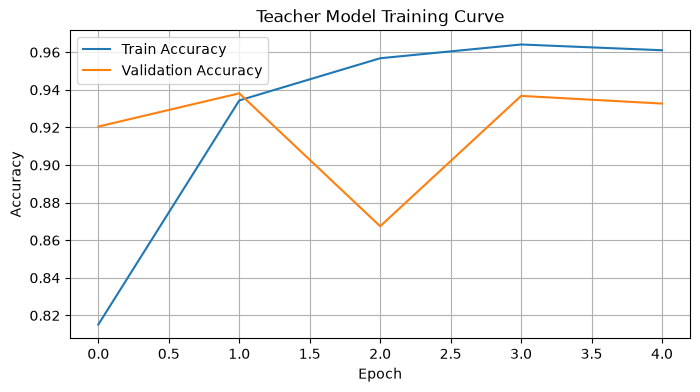

In [7]:

teacher_history_df = pd.DataFrame(teacher_history.history)

plt.figure(figsize=(8, 4))
plt.plot(teacher_history_df["accuracy"], label="Train Accuracy")
plt.plot(teacher_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Teacher Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 7. Evaluate the Teacher Model


In [8]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1,
)


Epoch 1/20
92/92 [==============================] - 0s 2ms/step - loss: 0.5301 - accuracy: 0.8123 - val_loss: 0.2443 - val_accuracy: 0.9103
Epoch 2/20
92/92 [==============================] - 0s 1ms/step - loss: 0.1845 - accuracy: 0.9345 - val_loss: 0.1950 - val_accuracy: 0.9177
Epoch 3/20
92/92 [==============================] - 0s 1ms/step - loss: 0.1514 - accuracy: 0.9415 - val_loss: 0.2699 - val_accuracy: 0.9123
Epoch 4/20
92/92 [==============================] - 0s 1ms/step - loss: 0.1158 - accuracy: 0.9565 - val_loss: 0.1503 - val_accuracy: 0.9347
Epoch 5/20
92/92 [==============================] - 0s 1ms/step - loss: 0.0891 - accuracy: 0.9663 - val_loss: 0.1711 - val_accuracy: 0.9252
Epoch 6/20
92/92 [==============================] - 0s 1ms/step - loss: 0.0669 - accuracy: 0.9779 - val_loss: 0.2556 - val_accuracy: 0.9184
Epoch 7/20
92/92 [==============================] - 0s 1ms/step - loss: 0.0642 - accuracy: 0.9765 - val_loss: 0.1501 - val_accuracy: 0.9381
Epoch 8/20
92/92 [==

## 8. Train a Baseline Student Model (Hard Labels Only)

Before applying knowledge distillation, we train the smaller student model in the standard way.  
This gives us a fair baseline for comparison.


In [15]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 0s 1ms/step - loss: 0.0394 - accuracy: 0.9838 - val_loss: 0.1787 - val_accuracy: 0.9470
Epoch 2/20
92/92 [==============================] - 0s 1ms/step - loss: 0.0377 - accuracy: 0.9852 - val_loss: 0.1276 - val_accuracy: 0.9572
Epoch 3/20
92/92 [==============================] - 0s 1ms/step - loss: 0.0261 - accuracy: 0.9900 - val_loss: 0.4236 - val_accuracy: 0.8770
Epoch 4/20
92/92 [==============================] - 0s 1ms/step - loss: 0.0445 - accuracy: 0.9832 - val_loss: 0.1455 - val_accuracy: 0.9504
Epoch 5/20
92/92 [==============================] - 0s 1ms/step - loss: 0.0230 - accuracy: 0.9903 - val_loss: 0.1346 - val_accuracy: 0.9592
Epoch 6/20
92/92 [==============================] - 0s 1ms/step - loss: 0.0251 - accuracy: 0.9900 - val_loss: 0.1822 - val_accuracy: 0.9531
Epoch 7/20
92/92 [==============================] - 0s 1000us/step - loss: 0.0326 - accuracy: 0.9881 - val_loss: 0.1108 - val_accuracy: 0.9585
Epoch 8/20
92/92 

## 9. Evaluate the Baseline Student Model


In [11]:

class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.3,
        temperature=4.0,
    ):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data
        teacher_predictions = self.teacher(x, training=False)
        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)
            student_loss = self.student_loss_fn(y, student_predictions)
            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1),
            ) * (self.temperature ** 2)
            loss = self.alpha * student_loss + (1.0 - self.alpha) * distillation_loss

        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.compiled_metrics.update_state(y, student_predictions)

        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "student_loss": student_loss,
            "distillation_loss": distillation_loss,
        })
        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)

        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)

        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results


# Part I: Knowledge Distillation

## 10. Distillation Utilities

The distilled student is trained to optimize:
- a **hard-label loss** using the true class labels
- a **soft-label loss** using the teacher's softened probability distribution


In [16]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1,
)


Epoch 1/20
92/92 [==============================] - 1s 2ms/step - accuracy: 0.7988 - student_loss: 0.5465 - distillation_loss: 0.0208 - val_accuracy: 0.9266 - val_student_loss: 0.0582
Epoch 2/20
92/92 [==============================] - 0s 1ms/step - accuracy: 0.9333 - student_loss: 0.1850 - distillation_loss: 0.0045 - val_accuracy: 0.9164 - val_student_loss: 0.0094
Epoch 3/20
92/92 [==============================] - 0s 1ms/step - accuracy: 0.9454 - student_loss: 0.1481 - distillation_loss: 0.0038 - val_accuracy: 0.9205 - val_student_loss: 0.0077
Epoch 4/20
92/92 [==============================] - 0s 1ms/step - accuracy: 0.9604 - student_loss: 0.1105 - distillation_loss: 0.0025 - val_accuracy: 0.9368 - val_student_loss: 0.0033
Epoch 5/20
92/92 [==============================] - 0s 1ms/step - accuracy: 0.9691 - student_loss: 0.0841 - distillation_loss: 0.0021 - val_accuracy: 0.9320 - val_student_loss: 8.0442e-04
Epoch 6/20
92/92 [==============================] - 0s 1ms/step - accuracy: 

## 11. Train the Distilled Student


In [17]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 0s 2ms/step - accuracy: 0.7698 - student_loss: 0.6131 - distillation_loss: 0.0243 - val_accuracy: 0.9143 - val_student_loss: 0.0677
Epoch 2/20
92/92 [==============================] - 0s 2ms/step - accuracy: 0.9180 - student_loss: 0.2183 - distillation_loss: 0.0060 - val_accuracy: 0.8967 - val_student_loss: 0.0159
Epoch 3/20
92/92 [==============================] - 0s 1ms/step - accuracy: 0.9476 - student_loss: 0.1478 - distillation_loss: 0.0031 - val_accuracy: 0.9198 - val_student_loss: 0.0115
Epoch 4/20
92/92 [==============================] - 0s 2ms/step - accuracy: 0.9568 - student_loss: 0.1172 - distillation_loss: 0.0025 - val_accuracy: 0.9347 - val_student_loss: 0.0065
Epoch 5/20
92/92 [==============================] - 0s 1ms/step - accuracy: 0.9685 - student_loss: 0.0906 - distillation_loss: 0.0020 - val_accuracy: 0.9266 - val_student_loss: 0.0012
Epoch 6/20
92/92 [==============================] - 0s 1ms/step - accuracy: 0.97

### Distillation Training Curves


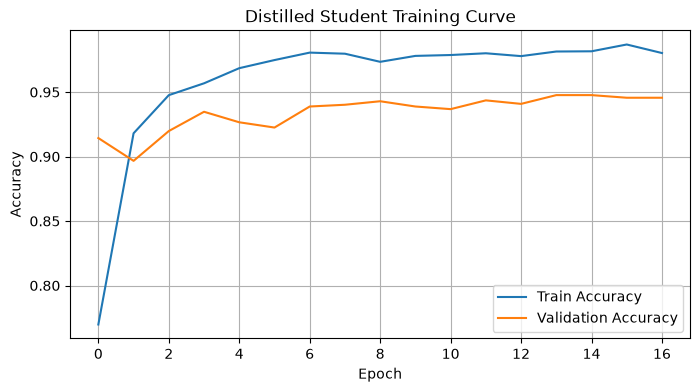

In [18]:

distillation_history_df = pd.DataFrame(distillation_history.history)

plt.figure(figsize=(8, 4))
plt.plot(distillation_history_df["accuracy"], label="Train Accuracy")
plt.plot(distillation_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Distilled Student Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 12. Evaluate the Distilled Student


Distilled Student Test Accuracy: 0.9352

                    precision    recall  f1-score   support

           WALKING     0.9381    0.9778    0.9576       496
  WALKING_UPSTAIRS     0.9498    0.9236    0.9365       471
WALKING_DOWNSTAIRS     0.9542    0.9429    0.9485       420
           SITTING     0.8954    0.9063    0.9008       491
          STANDING     0.8805    0.9004    0.8903       532
            LAYING     1.0000    0.9609    0.9801       537

          accuracy                         0.9352      2947
         macro avg     0.9363    0.9353    0.9356      2947
      weighted avg     0.9360    0.9352    0.9354      2947



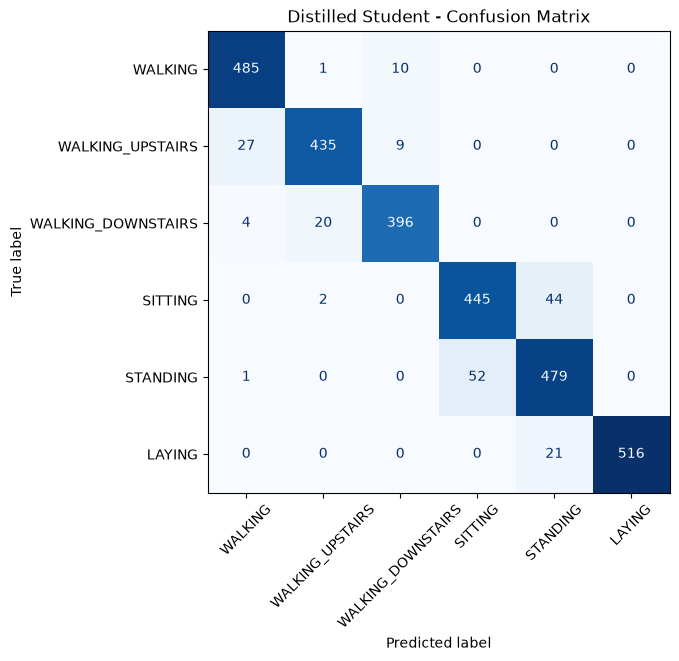

In [19]:

distilled_probs = distilled_student.predict(X_test, verbose=0)
distilled_preds = np.argmax(distilled_probs, axis=1)
distilled_acc = accuracy_score(y_test, distilled_preds)

print(f"Distilled Student Test Accuracy: {distilled_acc:.4f}\n")
print(classification_report(y_test, distilled_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, distilled_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Distilled Student - Confusion Matrix")
plt.show()


## 13. Part I Comparison: Teacher vs Student vs Distilled Student


In [20]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # Quantize the input when the model expects int8/uint8 input
        if input_details["dtype"] == np.int8:
            x = np.clip(np.round(x / input_scale + input_zero_point), -128, 127).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.clip(np.round(x / input_scale + input_zero_point), 0, 255).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # Dequantize the output when needed
        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    for i in range(300):
        yield [X_train[i:i+1]]


# Part II: Pruning and Quantization of the Distilled Student

## 14. TensorFlow Lite Utilities


In [22]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1]]


## 15. Convert the Distilled Student to TensorFlow Lite


In [24]:
pruning_epochs = 10
batch_size = 64
steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# TODO:
# 1. Clone the distilled student model.
# 2. Copy the distilled student weights into the cloned model.
# 3. Wrap the cloned model using prune_low_magnitude with pruning_params.

student_for_pruning = tf.keras.models.clone_model(distilled_student)
student_for_pruning.set_weights(distilled_student.get_weights())
pruned_distilled_model = prune_low_magnitude(student_for_pruning, **pruning_params)

pruned_distilled_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Fine-tune the pruned distilled model using:
# - X_train and y_train
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks
# - verbose=1
pruning_history = pruned_distilled_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1,
)

Epoch 1/10
92/92 [==============================] - 1s 2ms/step - loss: 0.0351 - accuracy: 0.9883 - val_loss: 0.1480 - val_accuracy: 0.9456
Epoch 2/10
92/92 [==============================] - 0s 1ms/step - loss: 0.0384 - accuracy: 0.9878 - val_loss: 0.1370 - val_accuracy: 0.9463
Epoch 3/10
92/92 [==============================] - 0s 1ms/step - loss: 0.0570 - accuracy: 0.9840 - val_loss: 0.1158 - val_accuracy: 0.9545
Epoch 4/10
92/92 [==============================] - 0s 1ms/step - loss: 0.0758 - accuracy: 0.9825 - val_loss: 0.1227 - val_accuracy: 0.9531
Epoch 5/10
92/92 [==============================] - 0s 1ms/step - loss: 0.1601 - accuracy: 0.9565 - val_loss: 0.1327 - val_accuracy: 0.9592
Epoch 6/10
92/92 [==============================] - 0s 1ms/step - loss: 0.7649 - accuracy: 0.7977 - val_loss: 0.5493 - val_accuracy: 0.8069
Epoch 7/10
92/92 [==============================] - 0s 1ms/step - loss: 1.2379 - accuracy: 0.6946 - val_loss: 1.3794 - val_accuracy: 0.5751
Epoch 8/10
92/92 [==

## 16. Apply Magnitude-Based Pruning to the Distilled Student


In [26]:

# TODO:
# Convert the pruned model with the pruning wrappers still attached.
pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_distilled_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_distilled_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

# TODO:
# Strip the pruning wrappers and convert again using sparse optimization.
stripped_pruned_model = strip_pruning(pruned_distilled_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "distilled_stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Pruned distilled model with mask accuracy: {pruned_with_mask_acc:.4f}")
print(f"Pruned distilled model with mask size (KB): {pruned_with_mask_size_kb:.2f}")
print(f"Stripped sparse distilled model accuracy: {stripped_sparse_acc:.4f}")
print(f"Stripped sparse distilled model size (KB): {stripped_sparse_size_kb:.2f}")


INFO:tensorflow:Assets written to: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmp0z35xkf3/assets


INFO:tensorflow:Assets written to: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmp0z35xkf3/assets
2026-07-15 01:33:53.386567: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 01:33:53.386585: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 01:33:53.386956: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmp0z35xkf3
2026-07-15 01:33:53.388312: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 01:33:53.388322: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmp0z35xkf3
2026-07-15 01:33:53.392035: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-07-15 01:33:53.393699: I tensorflow/cc/saved_model/load

INFO:tensorflow:Assets written to: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmpx_fezb61/assets


INFO:tensorflow:Assets written to: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmpx_fezb61/assets


Pruned distilled model with mask accuracy: 0.9342
Pruned distilled model with mask size (KB): 634.69
Stripped sparse distilled model accuracy: 0.9342
Stripped sparse distilled model size (KB): 127.98


2026-07-15 01:33:53.751908: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 01:33:53.751919: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 01:33:53.752016: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmpx_fezb61
2026-07-15 01:33:53.752287: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 01:33:53.752291: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmpx_fezb61
2026-07-15 01:33:53.752984: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-15 01:33:53.760233: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmpx_fezb61
2026-07-

## 17. Convert the Pruned Distilled Student Before and After Stripping


In [27]:

# TODO:
# Configure the converter for full integer quantization of the stripped sparse model.
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [
    tf.lite.Optimize.DEFAULT,
    tf.lite.Optimize.EXPERIMENTAL_SPARSITY
]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8


stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmp3cquklzv/assets


INFO:tensorflow:Assets written to: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmp3cquklzv/assets


Stripped Sparse + INT8 Accuracy: 0.9332
Stripped Sparse + INT8 Size (KB): 65.53


/Users/kourosh/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-07-15 01:34:47.655271: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 01:34:47.655298: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 01:34:47.655450: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmp3cquklzv
2026-07-15 01:34:47.655754: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 01:34:47.655758: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmp3cquklzv
2026-07-15 01:34:47.656643: I tensorflow/cc/saved_model/loader.cc:233] 

## 18. Apply Full Integer Quantization to the Stripped Sparse Distilled Student


In [28]:

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmp9uy792sz/assets


INFO:tensorflow:Assets written to: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmp9uy792sz/assets


Stripped Sparse + INT8 Accuracy: 0.9332
Stripped Sparse + INT8 Size (KB): 65.53


/Users/kourosh/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-07-15 01:35:28.164690: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 01:35:28.164717: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 01:35:28.164855: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmp9uy792sz
2026-07-15 01:35:28.165204: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 01:35:28.165209: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmp9uy792sz
2026-07-15 01:35:28.166046: I tensorflow/cc/saved_model/loader.cc:233] 

## 19. Part II Comparison: Distillation, Pruning, and Quantization


In [30]:
distilled_fp32_tflite = convert_to_tflite_fp32(distilled_student)
distilled_fp32_size_kb = save_binary_model(distilled_fp32_tflite, "distilled_student_fp32.tflite")
distilled_fp32_acc, distilled_fp32_preds = evaluate_tflite_model(distilled_fp32_tflite, X_test, y_test)

print(f"Distilled Student FP32 TFLite accuracy: {distilled_fp32_acc:.4f}")
print(f"Distilled Student FP32 TFLite size (KB): {distilled_fp32_size_kb:.2f}")

INFO:tensorflow:Assets written to: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmp4hof5cbb/assets


INFO:tensorflow:Assets written to: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmp4hof5cbb/assets


Distilled Student FP32 TFLite accuracy: 0.9352
Distilled Student FP32 TFLite size (KB): 316.89


2026-07-15 01:36:53.861409: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 01:36:53.861436: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 01:36:53.861578: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmp4hof5cbb
2026-07-15 01:36:53.861955: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 01:36:53.861960: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmp4hof5cbb
2026-07-15 01:36:53.862765: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-15 01:36:53.872815: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/wn/sc8rx18x2mv77cwtmrpd7jbc0000gn/T/tmp4hof5cbb
2026-07-

In [31]:

part2_results = pd.DataFrame([
    ["Distilled Student TFLite", "FP32", distilled_fp32_acc, distilled_fp32_size_kb],
    ["Pruned Distilled TFLite (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse Distilled TFLite", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
    ["Stripped Sparse Distilled TFLite", "INT8 + Sparse", stripped_sparse_int8_acc, stripped_sparse_int8_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part2_results


,Model,Format,Test Accuracy,Model Size (KB)
0,Distilled Student TFLite,FP32,0.935188,316.886719
1,Pruned Distilled TFLite (with mask),FP32,0.934170,634.687500
2,Stripped Sparse Distilled TFLite,FP32 + Sparse,0.934170,127.984375
3,Stripped Sparse Distilled TFLite,INT8 + Sparse,0.933152,65.531250


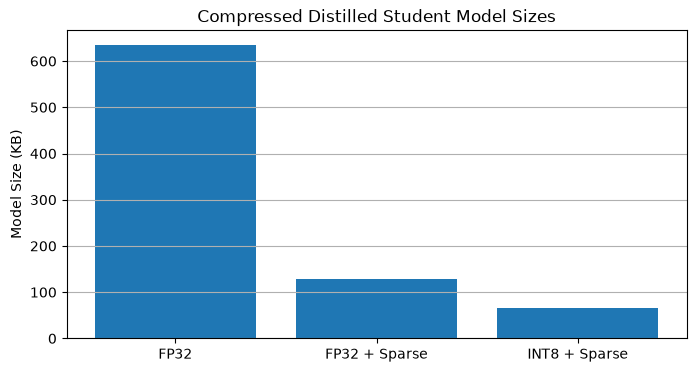

In [32]:

plt.figure(figsize=(8, 4))
plt.bar(part2_results["Format"], part2_results["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Compressed Distilled Student Model Sizes")
plt.grid(axis="y")
plt.show()


### Confusion Matrix for the Final Sparse INT8 Distilled Student


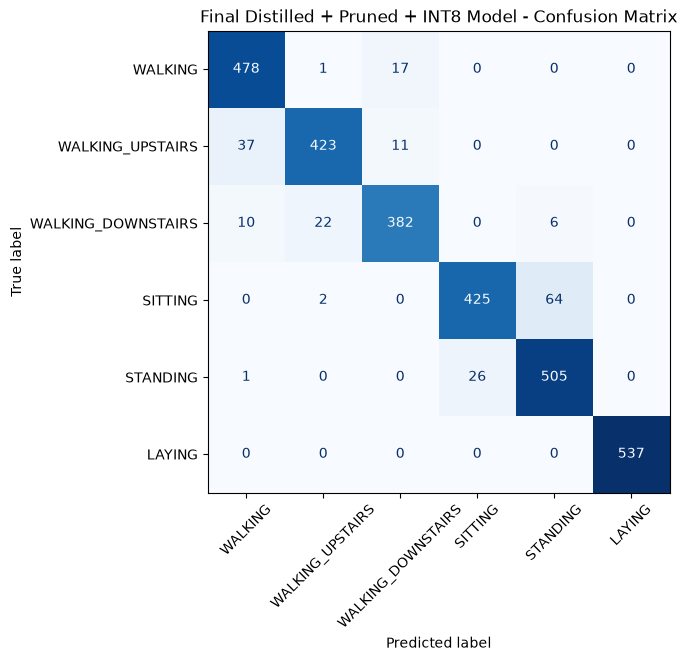

In [33]:

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_int8_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Final Distilled + Pruned + INT8 Model - Confusion Matrix")
plt.show()


## 20. Summary Questions

Answer the following in your lab report:
1. How did the **baseline student** compare with the **distilled student**?The baseline student (hard labels only) reached 0.9396 test accuracy; the distilled student reached 0.9352. Same architecture (80,582 params), same 20 epoch budget, same optimizer the distilled student was 0.0044 worse, about 13 samples. For context, the teacher itself only scored 0.9410, just 0.0014 above the baseline student four samples out of 2,947. A model with 5.6× the parameters knew essentially nothing the small one didn't, so there was no meaningful knowledge available to transfer.
2. Did **knowledge distillation** help the smaller model retain performance? No, and the training logs show two independent reasons. First, the teacher early-stopped at epoch 2 of 20 (val_accuracy peaked at 0.9381, then patience=3 fired after a val_loss spike at epoch 3), so it never became strong enough to teach. Second, both models end in a softmax layer, so tf.nn.softmax(teacher_predictions / T) applies a softmax to an already-normalized probability vector. A confident output like [0.99, 0.002 etc] divided by T=4 and re-softmaxed becomes approximately [0.204, 0.159, 0.159 etc] nearly uniform. The KL divergence between two near-uniform distributions is close to zero, and the logs confirm it: distillation_loss stayed around 0.002–0.003 while student_loss ran ~0.05. With alpha=0.3, the hard-label term supplied roughly 88% of the gradient despite the teacher nominally being weighted at 70%. The distilled student was effectively a baseline student trained with a reduced learning signal.
3. What happened to the model size after **pruning** and after **INT8 quantization**? The distilled student converted to 316.89 KB in FP32 TFLite. Pruning with the wrappers still attached produced 634.69 KB exactly 2.003× larger, because every weight gains a companion mask variable. After strip_pruning and export with EXPERIMENTAL_SPARSITY, it dropped to 127.98 KB (4.96× below the masked version, 2.48× below the plain FP32). Adding full INT8 quantization brought it to 65.53 KB. Notably, the two techniques did not compound cleanly: dense INT8 on 80,582 params would be roughly 79 KB, so 73.3% sparsity bought only ~17% beyond INT8 alone, because both are exploiting overlapping redundancy. Accuracy across the whole chain moved only 0.9352 → 0.9332.
4. Which model would you choose for **Arduino deployment**, and why? It depends on the constraint, and both candidates fit the Nano 33 BLE Sense's 1 MB flash. The final sparse INT8 distilled student (65.53 KB, 0.9332) is 2.8× smaller than the PTQ INT8 model from the quantization notebook (185.34 KB, 0.9433), but gives up 1.0% accuracy. If flash and RAM are tight  or the model shares the device with audio buffers, BLE stacks, and application code  65.53 KB is the right call. If there's headroom, PTQ INT8 is simpler to produce (no teacher, no distillation, no pruning schedule) and more accurate. Given that the Nano 33 BLE has 1 MB of flash, I would choose PTQ INT8 for this specific target: the size advantage is not needed, and 1% accuracy on a subject-wise split is worth more than 120 KB of unused flash. The distilled+pruned model becomes the better choice on a more constrained MCU.
5. Why is the final **sparse INT8 model** a good TinyML deployment candidate? It is fully integer end-to-end the conversion log confirms fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8 so it runs on an MCU with no floating-point unit, unlike the float16 variants. At 65.53 KB it is 27× smaller than the 1.73 MB teacher for a 0.78% accuracy cost (0.9410 → 0.9332). It reached that size through the cookbook's full pipeline: distillation reduced the architecture from 185K to 80K params, pruning zeroed 73.3% of what remained, stripping removed the masks, and sparse INT8 encoding compressed the rest. Its confusion matrix also shows the model retained the structurally important separations no static posture is ever confused with a dynamic activity, and LAYING is classified perfectly at 537/537, even at 27% of the original weight count.


## 21. Submission Requirements

Submit the following:
1. Your completed notebook
2. Screenshots of the most important results:
   - teacher accuracy
   - baseline student accuracy
   - distilled student accuracy
   - final sparse INT8 model accuracy and size
3. The exported TensorFlow Lite model:
   - `distilled_stripped_sparse_int8.tflite`
4. Short answers to the summary questions
